# 탐색적 데이터 분석 (EDA)

## EDA란?

**탐색적 데이터 분석**(Exploratory Data Analysis, EDA)은 데이터를 본격적으로 분석하거나 모델을 구축하기 전에
데이터의 구조, 분포, 패턴, 이상치 등을 파악하는 과정이다.
통계학자 존 튜키(John Tukey)가 1977년에 저서 *Exploratory Data Analysis*에서 체계적으로 정리한 개념으로,
"데이터가 무엇을 말하고 있는지 먼저 들어보자"는 철학을 담고 있다.

EDA는 데이터 분석 과정에서 가장 첫 번째이자 가장 중요한 단계이다.
아무리 정교한 머신러닝 모델이라도, 데이터를 충분히 이해하지 못한 채 적용하면 엉뚱한 결과를 낳을 수 있다.
EDA를 통해 우리는 다음 질문에 답할 수 있다.

- 데이터에 어떤 특성(feature)들이 있는가?
- 각 특성의 자료형은 무엇인가? (수치형, 범주형 등)
- 결측치(missing value)나 이상치(outlier)가 존재하는가?
- 특성들 사이에 어떤 관계가 있는가?
- 데이터의 분포는 어떤 형태인가?

### EDA 워크플로우

일반적인 EDA는 아래 순서를 따른다.

| 단계 | 내용 | 주요 도구 |
| :---: | :--- | :--- |
| 1 | **데이터 적재** — 파일이나 데이터베이스에서 데이터를 불러온다. | `pd.read_csv()` |
| 2 | **구조 파악** — 행/열 수, 자료형, 결측치 유무를 확인한다. | `shape`, `info()`, `dtypes` |
| 3 | **기초 통계** — 평균, 중위수, 분포 등 기술 통계량을 살펴본다. | `describe()`, `value_counts()` |
| 4 | **시각화** — 그래프를 통해 분포와 관계를 눈으로 파악한다. | `hist()`, `plot()`, `scatter_matrix()` |
| 5 | **상관관계 분석** — 특성 간 상관계수를 계산한다. | `corr()` |
| 6 | **데이터 전처리** — 결측치를 처리하고, 필요시 특성을 변환한다. | `fillna()`, `pd.cut()` |

이 챕터에서는 **캘리포니아 주택 데이터셋**을 활용하여 위 과정을 하나씩 실습한다.

## 기본 설정

EDA에 필요한 핵심 라이브러리를 불러온다.

- `numpy`: 수치 연산
- `pandas`: 데이터프레임 기반 데이터 처리
- `matplotlib.pyplot`: 데이터 시각화

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

데이터프레임 내 부동소수점을 소수점 이하 6자리까지만 출력하도록 지정한다.

In [2]:
pd.set_option('display.precision', 6)

실습 데이터가 저장된 원격 저장소의 URL을 지정한다.

In [3]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

## 1단계: 데이터 적재

EDA의 첫 단계는 분석 대상 데이터를 불러오는 것이다.
여기서 사용할 **캘리포니아 주택 데이터셋**은 1990년대 초 캘리포니아 주를 20,640개 구역으로 구분해
구역별 주택 통계를 수집한 데이터이다.

<div align="center"><img src="https://raw.githubusercontent.com/codingalzi/handson-ml3/master/jupyter-book/imgs/ch02/LA-USA01.png" width="600"></div>

구역별로 다음 10개 특성이 조사되었다.

| 특성 | 의미 | 자료형 |
| :--- | :--- | :---: |
| longitude | 경도 | 수치형 |
| latitude | 위도 | 수치형 |
| housing_median_age | 건축물 중위연령 | 수치형 |
| total_rooms | 방의 총 개수 | 수치형 |
| total_bedrooms | 침실 총 개수 | 수치형 |
| population | 인구 | 수치형 |
| households | 가구수 | 수치형 |
| median_income | 중위소득 | 수치형 |
| median_house_value | 중위 주택가격 | 수치형 |
| ocean_proximity | 해안 근접도 | 범주형 |

10개 특성 가운데 9개는 수치형이고, `ocean_proximity` 하나만 범주형이라는 점을 기억해두자.

`pd.read_csv()` 함수를 사용하여 CSV 파일을 데이터프레임으로 불러온다.

In [4]:
housing = pd.read_csv(data_url+'housing.csv')

## 2단계: 데이터 구조 파악

데이터를 불러온 직후 가장 먼저 해야 할 일은 데이터의 **크기와 구조**를 확인하는 것이다.
"데이터가 몇 행·몇 열인지", "각 열의 자료형은 무엇인지", "결측치는 없는지"를
빠르게 파악해야 이후 분석 방향을 정할 수 있다.

### 행과 열 확인

`shape` 속성으로 데이터프레임의 크기를 확인한다.
총 20,640개의 데이터 샘플(행)과 10개의 특성(열)이 포함되어 있다.

In [5]:
housing.shape

(20640, 10)

### 데이터 미리보기

`head()`와 `tail()` 메서드를 사용하면 데이터의 처음과 끝 몇 행을 빠르게 훑어볼 수 있다.
데이터가 제대로 불러와졌는지, 각 열에 어떤 종류의 값이 들어 있는지 감을 잡는 데 유용하다.

In [6]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
housing.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


### 열 이름 확인

`columns` 속성으로 모든 열(특성)의 이름을 확인한다.

In [8]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

### 자료형과 결측치 확인

`info()` 메서드는 EDA에서 가장 자주 사용되는 도구 중 하나이다.
각 열의 **자료형**(dtype)과 **비결측치 수**(Non-Null Count)를 한눈에 보여준다.

아래 결과에서 주목할 점은 다음 세 가지이다.

1. `ocean_proximity` 열의 자료형이 `str`(문자열)이다. → **범주형 특성**
2. 나머지 9개 열의 자료형은 `float64`이다. → **수치형 특성**
3. `total_bedrooms` 열의 Non-Null Count가 20,433으로 전체 20,640보다 적다. → **207개 결측치** 존재

In [9]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


## 3단계: 기초 통계 살펴보기

데이터의 구조를 파악했으니, 이제 각 특성에 어떤 값들이 들어 있는지 좀 더 자세히 살펴보자.
수치형 특성에는 기술 통계량을, 범주형 특성에는 고유값과 빈도를 확인한다.

### 수치형 특성: 기술 통계량

`describe()` 메서드는 수치형 열의 개수(count), 평균(mean), 표준편차(std), 
최솟값(min), 사분위수(25%, 50%, 75%), 최댓값(max)을 한눈에 보여준다.

In [10]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


몇 가지 눈에 띄는 점이 있다.

- `total_bedrooms`의 count가 20,433으로 다른 열(20,640)보다 작다. 이는 결측치가 207개 있다는 뜻이다.
- `median_house_value`의 max가 500,001이다. 상한이 잘려있을 가능성이 있다.
- `housing_median_age`의 max가 52로, 역시 상한이 잘려있을 수 있다.
- 각 특성의 스케일이 매우 다르다. 예를 들어 `median_income`은 0~15 범위인 반면, `population`은 3~35,682까지 분포한다.

하지만 `describe()`의 숫자만으로는 데이터의 전체적인 모습을 그리기 어렵다.
분포의 형태를 눈으로 확인하려면 시각화가 필요하다.

### 수치형 특성: 히스토그램

**히스토그램**(histogram)은 데이터를 일정한 구간(bin)으로 나누고,
각 구간에 속하는 데이터의 개수(빈도)를 막대 높이로 나타낸 그래프이다.
막대그래프와 비슷해 보이지만, 히스토그램은 **연속형 데이터의 분포**를 보여주는 데 사용하며,
막대가 서로 붙어 있다는 점에서 범주형 데이터를 나타내는 막대그래프와 구별된다.

`hist()` 메서드로 모든 수치형 열의 히스토그램을 한꺼번에 그려보면 분포를 직관적으로 파악할 수 있다.
`bins=50`은 데이터를 50개 구간으로 나눈다는 뜻이다.

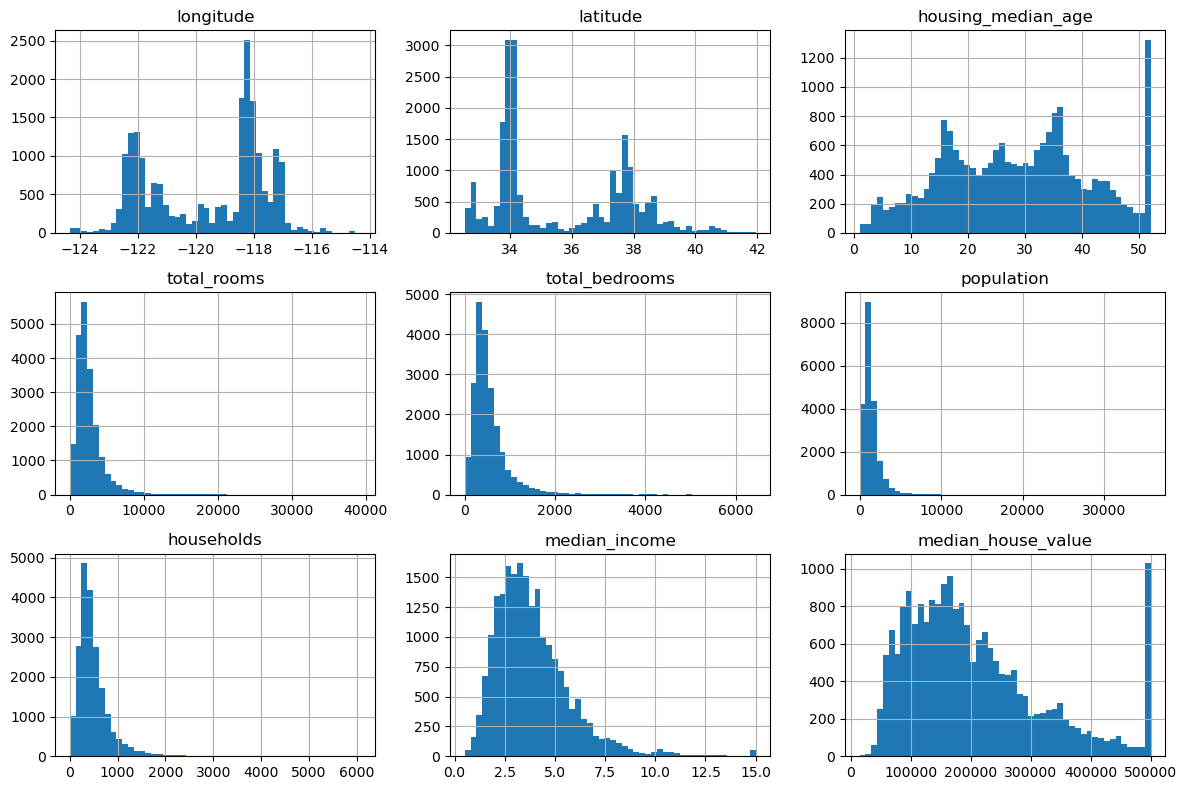

In [11]:
housing.hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

히스토그램에서 다음을 확인할 수 있다.

- **`median_income`**: 오른쪽으로 꼬리가 긴 분포(right-skewed)이다. 대부분의 구역에서 중간 소득이 2~5 사이에 몰려 있고, 고소득 구역은 소수에 불과하다. 참고로 이 값은 만 달러 단위로 스케일링된 값이다.
- **`median_house_value`**: 오른쪽 끝에 막대가 높게 솟아 있다. 이는 \$500,000를 초과하는 주택 가격이 모두 \$500,001로 잘린(capped) 것이다. 이 상한값에 몰린 데이터는 모델 학습 시 주의가 필요하다. 상한 이상의 정확한 가격을 예측해야 한다면 해당 구역을 제거하거나, 적절한 레이블을 다시 수집해야 할 수도 있다.
- **`housing_median_age`**: 마찬가지로 오른쪽 끝(52)에 막대가 솟아 있어, 52년 이상 된 주택이 모두 52로 잘렸음을 알 수 있다. 비교적 넓은 범위에 고르게 분포하는 편이다.
- **`total_rooms`, `total_bedrooms`, `population`, `households`**: 모두 강하게 오른쪽으로 치우친 분포를 보인다. 대부분의 구역이 작은 값에 집중되어 있고, 극단적으로 큰 값을 가진 구역이 소수 존재한다. 이러한 꼬리가 두꺼운(heavy-tailed) 분포는 이상치 탐지나 스케일링에 유의해야 한다.
- **`longitude`, `latitude`**: 지리 좌표이므로 캘리포니아의 지리적 형태에 따라 특정 위치에 데이터가 집중되어 있다. 예를 들어 longitude에서 -122 부근(샌프란시스코, 산호세 등 베이 에어리어)과 -118 부근(로스앤젤레스)에 뚜렷한 봉우리가 나타난다.
- 전반적으로 대부분의 특성이 정규분포와 거리가 멀다. 일부 머신러닝 알고리즘은 입력 특성이 정규분포에 가까울 때 더 잘 작동하므로, 나중에 변환(예: 로그 변환)을 고려해 볼 수 있다.

### 범주형 특성: 해안 근접도

유일한 범주형 특성인 `ocean_proximity`는 각 구역이 바다로부터 얼마나 가까운지를 5개 범주로 나타낸다.

| 해안 근접도 | 의미 |
| :--- | :--- |
| NEAR BAY | 샌프란시스코 Bay Area 근처 |
| <1H OCEAN | 바다로부터 1시간 이내 |
| INLAND | 내륙 |
| NEAR OCEAN | 해안가 |
| ISLAND | 섬 |

`unique()` 메서드로 고유값을, `value_counts()` 메서드로 각 범주의 빈도를 확인한다.

In [12]:
ocean_proximity_values = housing["ocean_proximity"].unique()
ocean_proximity_values

<ArrowStringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [13]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

범주별 빈도를 막대그래프로 시각화하면 차이를 직관적으로 파악할 수 있다.

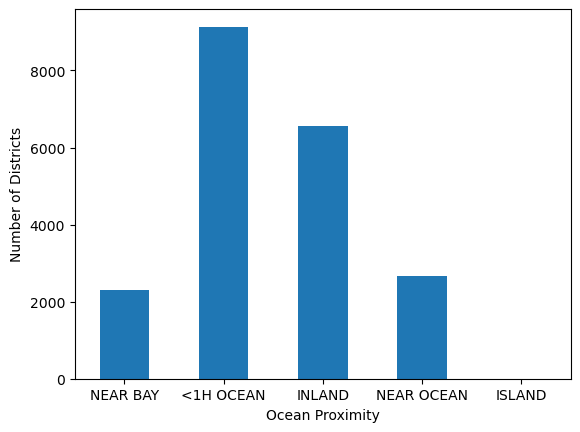

In [14]:
housing["ocean_proximity"].value_counts().loc[ocean_proximity_values].plot(kind='bar', rot=0)
plt.xlabel("Ocean Proximity")
plt.ylabel("Number of Districts")
plt.show()

바다에서 1시간 이내 거리(`<1H OCEAN`)에 있는 구역이 9,136개로 가장 많고,
섬(`ISLAND`)에 해당하는 구역은 5개뿐이다.
이처럼 범주별 빈도에 큰 차이가 있을 때, 분석 시 소수 범주의 영향력을 고려해야 한다.

## 4단계: 시각화를 통한 탐색

숫자만으로는 데이터의 전체적인 모습을 그리기 어렵다.
시각화는 데이터의 분포, 군집, 이상치를 직관적으로 파악하게 해주는 EDA의 핵심 도구이다.

> "그래프 하나가 숫자 천 개보다 낫다."

### 위치 정보 시각화

경도(longitude)와 위도(latitude) 정보를 산점도로 그리면 캘리포니아의 지리적 형태가 그대로 나타난다.
`alpha=0.3`으로 투명도를 주면, 데이터가 밀집된 지역(대도시)이 더 진하게 보인다.

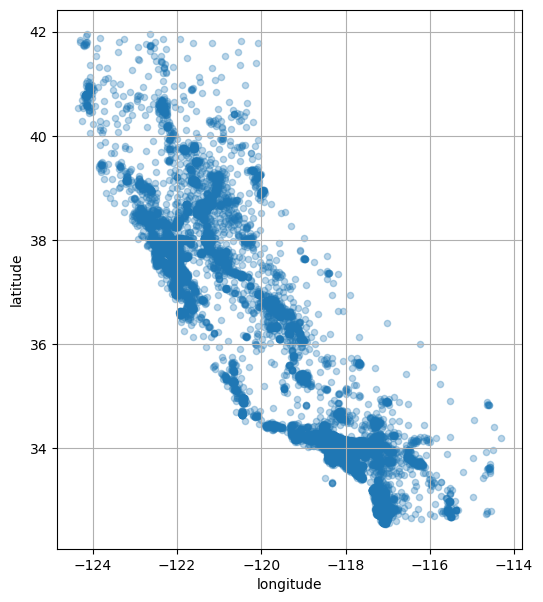

In [15]:
housing.plot(kind="scatter", 
             x="longitude",
             y="latitude",
             grid=True,
             alpha=0.3,
             figsize=(6, 7))
plt.show()

산점도가 캘리포니아 지도와 거의 일치한다. 
LA, 샌프란시스코, 산호세 등 대도시 주변에 점이 밀집되어 있음을 알 수 있다.

여기에 추가 정보를 더 입혀보자.
원의 **크기**로 구역별 인구를, 원의 **색상**으로 중위 주택가격을 표현하면
하나의 그래프에서 네 가지 특성(경도, 위도, 인구, 주택가격)을 동시에 볼 수 있다.

- `s=housing["population"] / 100` : 구역별 인구에 비례해서 원의 크기 지정
- `c="median_house_value"` : 중위 주택가격을 색상 지정에 이용
- `cmap="turbo"` : [colormap 지정](https://matplotlib.org/stable/tutorials/colors/colormaps.html)

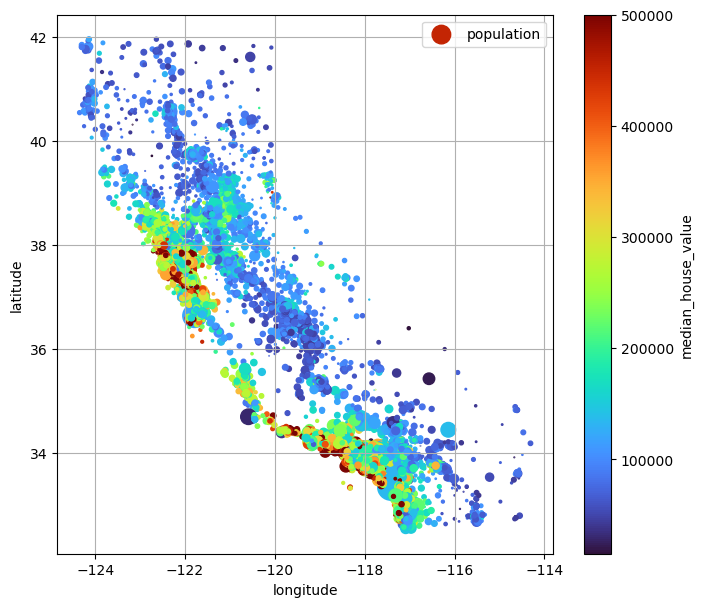

In [16]:
ax = housing.plot(kind="scatter", 
                  x="longitude", 
                  y="latitude", 
                  grid=True,
                  s=housing["population"] / 100, label="population",
                  c="median_house_value", 
                  cmap="turbo", 
                  colorbar=True,
                  figsize=(8, 7))
plt.show()

해안가, 특히 LA와 샌프란시스코 Bay Area 근처의 주택가격이 높게 나타난다(빨간색).
반면 내륙 지역은 상대적으로 낮은 가격(파란색)을 보인다.
이처럼 시각화를 통해 **위치가 주택가격에 큰 영향을 미친다**는 직관을 얻을 수 있다.

### 해안 근접도 시각화

앞서 확인한 범주형 특성 `ocean_proximity`를 지도 위에 색으로 표현해보자.
단, 산점도에서 색상을 지정하려면 범주를 숫자로 변환해야 한다.
`pd.factorize()` 함수가 이 역할을 한다.

| 해안 근접도 | 숫자 코드 |
| :---: | :---: |
| NEAR BAY | 0 |
| <1H OCEAN | 1 |
| INLAND | 2 |
| NEAR OCEAN | 3 |
| ISLAND | 4 |

In [17]:
pd.factorize(housing["ocean_proximity"])

(array([0, 0, 0, ..., 2, 2, 2], shape=(20640,)),
 Index(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'], dtype='str'))

`pd.factorize()`는 두 항목으로 구성된 튜플을 반환한다.

- 첫째 항목: 범주를 숫자로 변환한 넘파이 어레이
- 둘째 항목: 숫자-범주 매핑을 보여주는 인덱스

첫째 항목을 이용하여 `ocean_p`라는 새 열을 추가한다.

In [18]:
housing["ocean_p"] = pd.factorize(housing["ocean_proximity"])[0]

이제 해안 근접도를 색상으로 입힌 산점도를 그린다.
범주형 데이터이므로 색상이 뚜렷하게 구분되는 `tab10` 컬러맵을 사용하고,
colorbar의 눈금에 범주 이름을 표시한다.

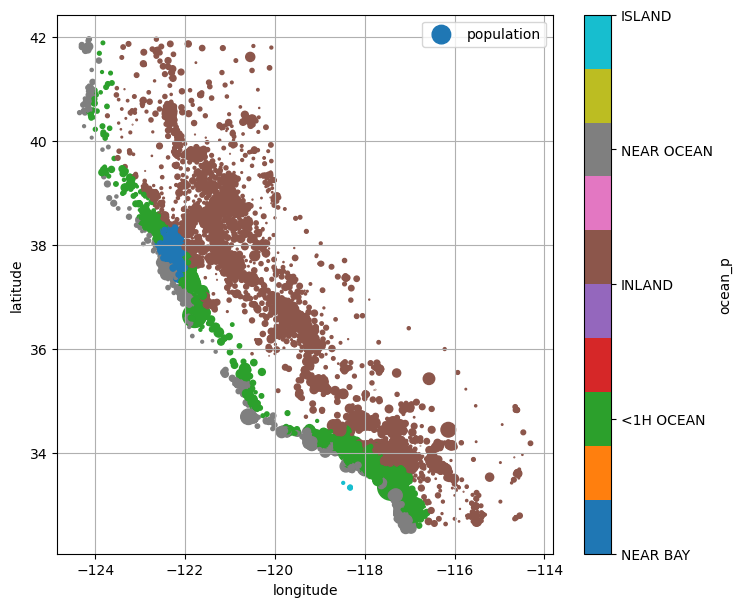

In [19]:
ax = housing.plot(kind="scatter", 
                  x="longitude", 
                  y="latitude",
                  grid=True,
                  s=housing["population"] / 100, label="population",
                  c="ocean_p", 
                  cmap="tab10", 
                  colorbar=True,
                  figsize=(8, 7))

# colorbar의 눈금과 레이블 설정
cb = ax.collections[0].colorbar
cb.set_ticks([0, 1, 2, 3, 4])
cb.set_ticklabels(housing["ocean_proximity"].unique())

plt.show()

해안가 구역(NEAR BAY, <1H OCEAN, NEAR OCEAN)과 내륙 구역(INLAND)이
지리적으로 명확히 구분되는 것을 볼 수 있다.
이런 시각적 확인을 통해 `ocean_proximity` 특성이 주택가격 예측에 유용할 수 있다는 가설을 세울 수 있다.

## 5단계: 상관관계 분석

수치형 특성들 사이에 어떤 선형 관계가 있는지 파악하는 것은 EDA의 핵심이다.
예를 들어, **피어슨 상관계수**(Pearson correlation coefficient)는
두 특성 사이의 선형 관계 강도를 -1에서 1 사이의 값으로 나타낸다.

- **1에 가까울수록**: 강한 양의 상관관계 (한쪽이 커지면 다른 쪽도 커진다)
- **-1에 가까울수록**: 강한 음의 상관관계 (한쪽이 커지면 다른 쪽은 작아진다)
- **0에 가까울수록**: 선형 관계가 거의 없다

피어슨 상관계수를 계산하는 방식과 다양한 선형 관계 사례는 이어지는 장(chapter)에서 소개한다.
여기서는 두 수치형 특성의 피어슨 상관계수의 절댓값이 1에 가까울 수록
두 특성이 선형적으로 상관관계가 크다라는 정도만 받아들이면 된다.

### 두 특성의 선형 상관관계

아래 코드는 중위소득(`median_income`)과 중위 주택가격(`median_house_value`) 두 특성의 선형 상관관계를 피어슨 상관계수로 계산한다.
데이터프레임의 `corr()` 메서드는 두 개의 수치형 특성들 사이의 피어슨 상관계수로 구성된 상관계수 행렬을 반환한다.

In [20]:
corr_matrix = housing.loc[:, ['median_income', 'median_house_value']].corr()
corr_matrix

,median_income,median_house_value
median_income,1.000000,0.688075
median_house_value,0.688075,1.000000


피어슨 상관계수가 약 0.688로, 중위소득과 중위 주택가격 사이에 **비교적 강한 양의 상관관계**가 있다.
즉, 소득이 높은 구역일수록 주택가격도 높은 경향이 있음을 보여준다.
산점도를 이용하면 이 관계를 시각적으로 확인할 수 있다.

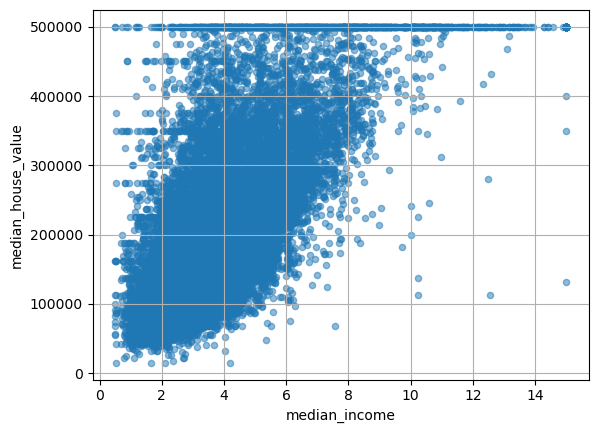

In [21]:
housing.plot(kind="scatter", 
             x="median_income", 
             y="median_house_value",
             alpha=0.5, 
             grid=True)
plt.show()

산점도에서 전반적으로 우상향하는 경향이 보인다.
하지만 한 가지 이상한 점이 눈에 띈다.
중위 주택가격 50만 달러 부근에 **수평선처럼 데이터가 몰려 있다**.
이것은 아마도 50만 달러 이상의 주택가격을 일괄적으로 50만 달러로 잘라낸(cap) 결과로 보인다.

이런 패턴을 발견하는 것이 바로 EDA의 가치이다.
이 이상치들은 분석이나 모델링 전에 적절히 처리해야 한다.

### 여러 특성의 상관행렬

두 특성만으로는 전체 그림을 파악하기 어렵다.
주택가격과 관련이 깊을 것으로 예상되는 핵심 특성 몇 개를 골라 상관행렬을 구해보자.

- `median_income` : 중위소득 — 주택가격과 가장 강한 상관관계가 예상됨
- `total_rooms` : 전체 방 수 — 주거 규모
- `housing_median_age` : 건물 연식 — 노후도가 가격에 미치는 영향
- `median_house_value` : 중위 주택가격 — 예측 대상(타겟)

In [22]:
cols = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']
housing[cols].corr()

,median_house_value,median_income,total_rooms,housing_median_age
median_house_value,1.000000,0.688075,0.134153,0.105623
median_income,0.688075,1.000000,0.198050,-0.119034
total_rooms,0.134153,0.198050,1.000000,-0.361262
housing_median_age,0.105623,-0.119034,-0.361262,1.000000


상관행렬을 숫자로 읽는 것도 좋지만, **히트맵**(heatmap)으로 시각화하면 색상의 진하기로 상관관계의 강도를 직관적으로 파악할 수 있다.

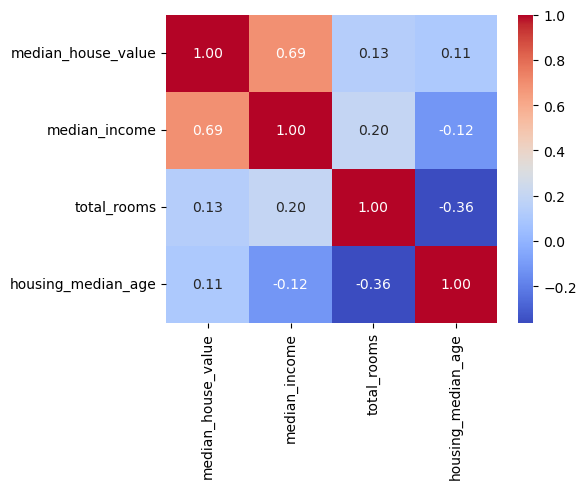

In [23]:
corr = housing[cols].corr()

import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
plt.tight_layout()
plt.show()

히트맵에서 `median_income`과 `median_house_value` 교차 지점이 가장 진한 빨간색(0.69)으로 나타난다.
반면 `housing_median_age`는 다른 특성과의 상관관계가 모두 약해서 흰색에 가깝다.
이처럼 히트맵은 어떤 특성 쌍이 강한 관계를 가지는지 한눈에 보여준다.

타겟과의 상관계수만 따로 뽑아 정렬하면 어떤 특성이 가장 관련이 깊은지 더 명확하게 알 수 있다.

In [24]:
housing[cols].corr()['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
Name: median_house_value, dtype: float64

## 6단계: 데이터 전처리

EDA를 통해 데이터의 문제점을 발견했다면, 분석에 앞서 이를 정리해야 한다.
이 데이터셋에서는 두 가지 문제를 처리해야 한다.

1. **이상치(outlier)** — 중위 주택가격 50만 달러 부근의 비정상적 데이터
2. **결측치(missing value)** — `total_bedrooms` 열의 누락된 값 207개

### 이상치 처리

앞서 상관관계 산점도에서 중위 주택가격이 50만 달러 부근에 수평으로 몰려 있는 패턴을 발견했다.
이런 데이터는 현실에서 자연스럽게 발생할 수 없으므로,
50만 달러 이상의 값을 일괄적으로 잘라낸(cap) 결과로 추정된다.

`value_counts()`로 확인해보면, 정확히 500,001달러인 샘플이 965개 존재한다.

In [25]:
housing.median_house_value.value_counts()

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
           ... 
327900.0      1
438800.0      1
455500.0      1
200700.0      1
47000.0       1
Name: count, Length: 3842, dtype: int64

500,001달러 샘플이 가장 많다.
이 데이터는 실제 주택가격이 아니라 상한선이 적용된 인위적 값이므로 **이상치로 간주하고 제거**한다.

In [26]:
mask_outlier = housing.median_house_value != 500001
housing = housing[mask_outlier].copy()

제거 후 가장 비싼 중위 주택가격은 50만 달러로 확인된다.

In [27]:
housing.median_house_value.describe()

count     19675.000000
mean     192477.921017
std       97711.509613
min       14999.000000
25%      116600.000000
50%      173800.000000
75%      248200.000000
max      500000.000000
Name: median_house_value, dtype: float64

산점도를 다시 그리면, 50만 달러 부근의 수평선이 사라진 것을 확인할 수 있다.

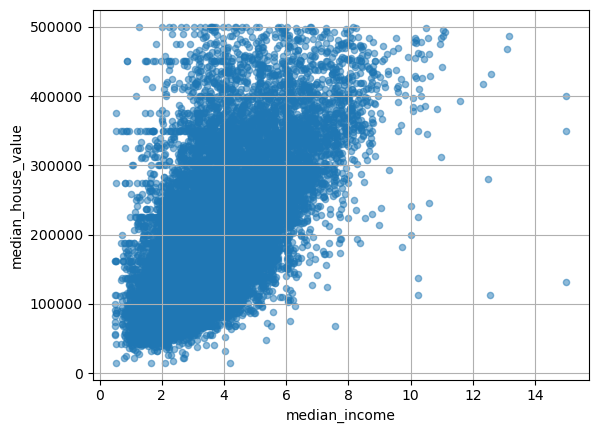

In [28]:
housing.plot(kind="scatter", 
             x="median_income", 
             y="median_house_value",
             alpha=0.5, 
             grid=True)
plt.show()

### 결측치 확인

앞서 `info()`를 통해 `total_bedrooms` 열에 결측치가 있음을 확인했다.
이상치를 제거한 후의 결측치 수를 `isnull().sum()`으로 다시 확인한다.

In [29]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        200
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
ocean_p                 0
dtype: int64

결측치를 포함한 행을 직접 확인해보자.

In [30]:
mask = housing['total_bedrooms'].isnull()
housing[mask]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_p
182,-118.27,34.04,13.0,1784.0,NaN,2158.0,682.0,1.7038,118100.0,<1H OCEAN,1
327,-117.65,34.04,15.0,3393.0,NaN,2039.0,611.0,3.9336,151000.0,INLAND,2
366,-122.50,37.75,44.0,1819.0,NaN,1137.0,354.0,3.4919,271800.0,NEAR OCEAN,3
477,-117.99,34.14,30.0,2346.0,NaN,1988.0,474.0,2.5625,153000.0,INLAND,2
495,-114.59,34.83,41.0,812.0,NaN,375.0,158.0,1.7083,48500.0,INLAND,2
...,...,...,...,...,...,...,...,...,...,...,...
19880,-118.23,33.94,36.0,1110.0,NaN,1417.0,302.0,2.3333,92100.0,<1H OCEAN,1
19952,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN,3
20088,-119.73,36.83,8.0,3602.0,NaN,1959.0,580.0,5.3478,138800.0,INLAND,2
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN,1


In [31]:
housing[mask].shape

(200, 11)

### 결측치 처리

결측치를 처리하는 대표적인 방법은 세 가지이다.

| 방법 | 설명 | 사용 시점 |
| :--- | :--- | :--- |
| **삭제** | 결측치가 있는 행을 제거 | 결측치가 매우 적을 때 |
| **대체** | 평균, 중위수 등으로 채움 | 결측치가 적당할 때 |
| **예측** | 다른 특성으로 결측치를 추정 | 결측치가 많고 패턴이 있을 때 |

여기서는 `total_bedrooms` 열의 **중위수**(median)로 결측치를 채우는 방법을 사용한다.
중위수는 이상치에 덜 민감하므로 평균보다 안정적인 대체값이 된다.

In [32]:
median = housing["total_bedrooms"].median()
housing.loc[:, "total_bedrooms"] = housing.loc[:, "total_bedrooms"].fillna(median)

`info()`로 결측치가 모두 사라졌는지 확인한다.

In [33]:
housing.info()

<class 'pandas.DataFrame'>
Index: 19675 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           19675 non-null  float64
 1   latitude            19675 non-null  float64
 2   housing_median_age  19675 non-null  float64
 3   total_rooms         19675 non-null  float64
 4   total_bedrooms      19675 non-null  float64
 5   population          19675 non-null  float64
 6   households          19675 non-null  float64
 7   median_income       19675 non-null  float64
 8   median_house_value  19675 non-null  float64
 9   ocean_proximity     19675 non-null  str    
 10  ocean_p             19675 non-null  int64  
dtypes: float64(9), int64(1), str(1)
memory usage: 2.0 MB


이전에 결측치가 있던 행의 `total_bedrooms` 값이 중위수로 채워졌는지 확인한다.

In [34]:
housing[['total_bedrooms']][mask]

,total_bedrooms
182,436.0
327,436.0
366,436.0
477,436.0
495,436.0
...,...
19880,436.0
19952,436.0
20088,436.0
20325,436.0


최종적으로, 전체 데이터프레임에 결측치가 하나도 없음을 확인한다.

In [35]:
housing.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
ocean_p               0
dtype: int64

## 정리

이 챕터에서는 캘리포니아 주택 데이터셋을 활용하여 EDA의 전체 흐름을 실습했다.

| 단계 | 수행 내용 | 발견한 사실 |
| :---: | :--- | :--- |
| 데이터 적재 | CSV 파일을 데이터프레임으로 불러옴 | 20,640개 샘플, 10개 특성 |
| 구조 파악 | `shape`, `info()` 등으로 기본 정보 확인 | `total_bedrooms`에 결측치 207개 |
| 기초 통계 | 범주형 특성의 고유값과 빈도 확인 | `<1H OCEAN` 범주가 가장 많음 |
| 시각화 | 산점도, 막대그래프 등으로 분포 탐색 | 해안가 구역의 주택가격이 높음 |
| 상관관계 | 수치형 특성 간 상관계수 계산 | 중위소득과 주택가격의 상관계수 ≈ 0.69 |
| 전처리 (이상치) | 500,001달러 cap 데이터 965개 제거 | 인위적 상한선 제거로 분포 정상화 |
| 전처리 (결측치) | 결측치를 중위수로 대체 | 207개 결측치 모두 처리 완료 |

EDA는 정해진 공식이 있는 것이 아니라, 데이터에 대한 궁금증을 하나씩 풀어가는 **탐험** 과정이다.
좋은 질문을 던지고, 데이터로 답을 구하고, 그 답에서 또 새로운 질문을 떠올리는 반복이
EDA의 본질이라 할 수 있다.

## 연습문제

타이타닉 데이터셋을 활용하여 이 챕터에서 배운 EDA 과정을 복습한다.

타이타닉 데이터셋은 1912년 타이타닉호 침몰 사고 당시 승객 891명의 정보를 담고 있다.

| 특성 | 의미 | 자료형 |
| :--- | :--- | :---: |
| PassengerId | 승객 번호 | 수치형 |
| Survived | 생존 여부 (0: 사망, 1: 생존) | 범주형 |
| Pclass | 객실 등급 (1, 2, 3등급) | 범주형 |
| Name | 이름 | 문자열 |
| Sex | 성별 | 범주형 |
| Age | 나이 | 수치형 |
| SibSp | 동반 형제자매/배우자 수 | 수치형 |
| Parch | 동반 부모/자녀 수 | 수치형 |
| Ticket | 티켓 번호 | 문자열 |
| Fare | 운임 | 수치형 |
| Cabin | 객실 번호 | 문자열 |
| Embarked | 탑승 항구 (C, Q, S) | 범주형 |

아래 코드로 타이타닉 데이터셋을 불러온다.

In [36]:
titanic = pd.read_csv(data_url + 'titanic.csv')
titanic = titanic.set_index("PassengerId")

**문제 1**

타이타닉 데이터셋의 구조를 파악하라.

(1) 데이터셋의 행과 열의 개수를 확인하라.

(2) 처음 5개의 행을 확인하라.

(3) 각 열의 데이터 타입과 결측치 개수를 확인하라.

답:

(1) `shape` 속성을 사용한다.

In [37]:
titanic.shape

(891, 11)

(2) `head()` 메서드를 사용한다.

In [38]:
titanic.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


(3) `info()` 메서드를 사용한다. 결측치가 있는 열은 `Age`(177개), `Cabin`(687개), `Embarked`(2개)이다.

In [39]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 111.9 KB


**문제 2**

타이타닉 데이터셋의 기초 통계를 확인하라.

(1) 수치형 열의 기초 통계량을 확인하라.

(2) `Pclass`(객실 등급) 열의 고유값과 각 값의 빈도를 확인하라.

(3) `Survived`(생존 여부) 열의 평균을 구하라. 이 값이 의미하는 바를 설명하라.

답:

(1) `describe()` 메서드를 사용한다.

In [40]:
titanic.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


(2) `unique()`와 `value_counts()` 메서드를 사용한다. 객실 등급은 1등급, 2등급, 3등급 세 종류이며, 3등급 승객이 가장 많다.

In [41]:
print("고유값:", titanic['Pclass'].unique())
titanic['Pclass'].value_counts()

고유값: [3 1 2]


Pclass
3    491
1    216
2    184
Name: count, dtype: int64

(3) `Survived` 열의 평균은 생존율을 의미한다. 0(사망)과 1(생존)로 이루어진 열이므로 평균이 곧 생존 비율이다.

In [42]:
titanic['Survived'].mean()

np.float64(0.3838383838383838)

**문제 3**

타이타닉 데이터셋을 시각화하라.

(1) `Age` 열의 히스토그램을 그려라. 구간(bins)은 30으로 지정하라.

(2) `Survived` 열의 값별 빈도를 막대그래프로 나타내라.

(3) `Age`와 `Fare`의 산점도를 그려라. 생존 여부(`Survived`)에 따라 색을 다르게 표시하라.

답:

(1) `hist()` 메서드를 사용한다.

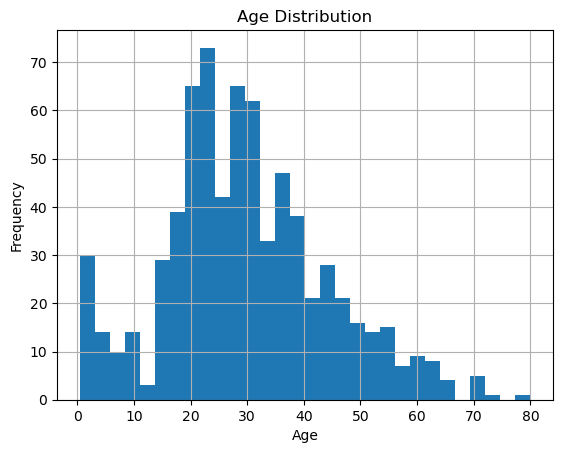

In [43]:
titanic['Age'].hist(bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

(2) `value_counts()`로 빈도를 구한 후 `plot(kind='bar')`로 막대그래프를 그린다.

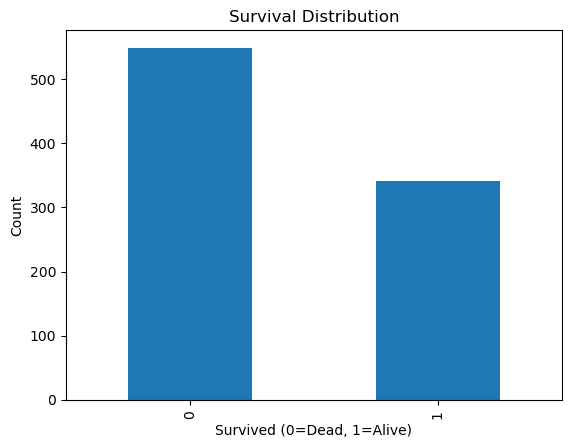

In [44]:
titanic['Survived'].value_counts().plot(kind='bar')
plt.xlabel('Survived (0=Dead, 1=Alive)')
plt.ylabel('Count')
plt.title('Survival Distribution')
plt.show()

(3) `plt.scatter()`를 사용하며, `c` 매개변수로 `Survived` 열을 지정하여 색을 다르게 표시한다.

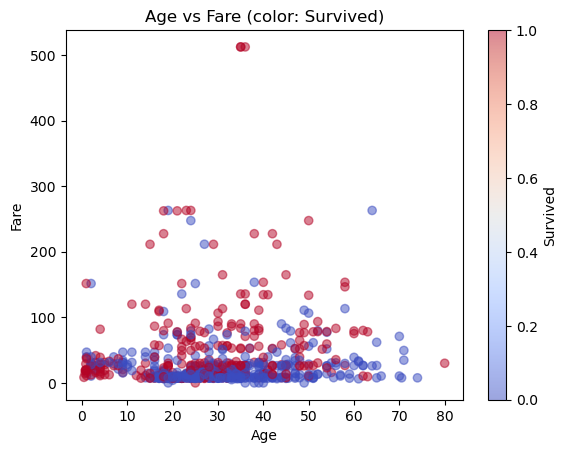

In [45]:
plt.scatter(titanic['Age'], titanic['Fare'], c=titanic['Survived'], cmap='coolwarm', alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare (color: Survived)')
plt.colorbar(label='Survived')
plt.show()

**문제 4**

타이타닉 데이터셋의 수치형 열 사이의 상관관계를 분석하라.

(1) 수치형 열의 상관행렬을 구하라.

(2) `Survived`와 가장 양의 상관관계가 가장 높은 열과 음의 상관관계가 가장 높은 열을 찾아라.

(3) `Fare`와 `Pclass`의 관계를 산점도로 그려라.

답:

(1) `corr()` 메서드를 사용한다. `numeric_only=True`를 지정하여 수치형 열만 대상으로 한다.

In [46]:
corr_matrix = titanic.corr(numeric_only=True)
corr_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


(2) `Survived` 행(또는 열)을 선택한 후 `sort_values()`로 정렬한다. 자기 자신(1.0)을 제외하면 `Fare`와 가장 양의 상관관계가 높고, `Pclass`와 가장 음의 상관관계가 높다(즉, 등급이 낮을수록(3등급) 생존율이 낮다).

In [47]:
corr_matrix['Survived'].sort_values()

Pclass     -0.338481
Age        -0.077221
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Survived    1.000000
Name: Survived, dtype: float64

(3) `Fare`와 `Pclass`의 산점도이다. 1등급일수록 요금이 높은 경향이 뚜렷하다.

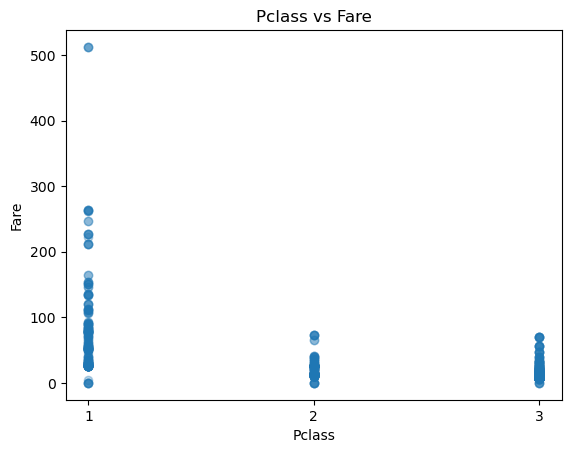

In [48]:
plt.scatter(titanic['Pclass'], titanic['Fare'], alpha=0.3)
plt.xlabel('Pclass')
plt.ylabel('Fare')
plt.title('Pclass vs Fare')
plt.xticks([1, 2, 3])
plt.show()

**문제 5**

타이타닉 데이터셋의 결측치를 처리하라.

(1) 각 열의 결측치 개수를 확인하라.

(2) `Age` 열의 결측치를 중위수로 채워라.

(3) `Embarked` 열의 결측치를 최빈값으로 채워라.

(4) 결측치 처리 후 전체 결측치 개수를 다시 확인하라. (`Cabin` 열은 제외한다.)

답:

(1) `isnull().sum()`을 사용한다.

In [49]:
titanic.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

(2) `fillna()` 메서드에 `median()` 값을 전달한다.

In [50]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Age'].isnull().sum()

np.int64(0)

(3) `mode()` 메서드로 최빈값을 구한 후 `fillna()`로 채운다. `mode()`는 시리즈를 반환하므로 `[0]`으로 첫 번째 값을 선택한다.

In [51]:
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
titanic['Embarked'].isnull().sum()

np.int64(0)

(4) `Cabin` 열을 제외하고 결측치를 확인한다. `Age`와 `Embarked` 열의 결측치가 모두 0으로 처리되었다.

In [52]:
titanic.drop(columns='Cabin').isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64